# Way 1: From Scratch - Understanding What PolynomialFeatures Does

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Original X shape: (10,)
Polynomial X shape: (10, 3)

First 3 rows of polynomial features:
[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]
Theta_0: 18.5667
Theta_1: 18.1015
Theta_2: -1.2500


Equation: ŷ = 18.57 + 18.10x + -1.25x²


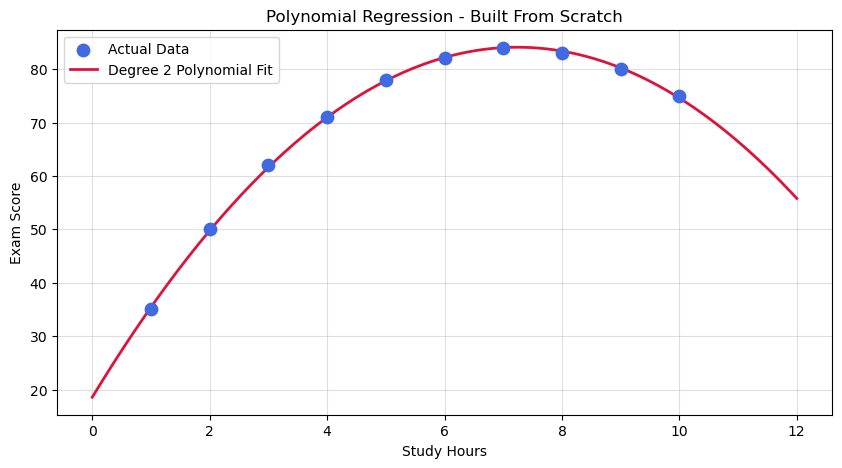

In [2]:
# Simple curved data
# Study hours vs score - but now score plateaus after too many hours
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype = float)
y = np.array([35, 50, 62, 71, 78, 82, 84, 83, 80, 75], dtype = float)

# Notice: score peaks around 7-8 hours then drops - classical parabola

# Manually create polynomial features
# Transform x into [1, x, x2]
X_poly_manual = np.column_stack([
    np.ones(len(X)), # bias column - theta0
    X, # x - theta1
    X**2 # x squared - theta2
])

print("="* 30)
print("Original X shape:", X.shape)
print("Polynomial X shape:", X_poly_manual.shape)
print("\nFirst 3 rows of polynomial features:")
print(X_poly_manual[:3])
print("="* 30)


# OLS solution - same formula as always
theta = np.linalg.inv(X_poly_manual.T @ X_poly_manual) @ X_poly_manual.T @ y

print(f"Theta_0: {theta[0]:.4f}")
print(f"Theta_1: {theta[1]:.4f}")
print(f"Theta_2: {theta[2]:.4f}")
print()
print(f"\nEquation: ŷ = {theta[0]:.2f} + {theta[1]:.2f}x + {theta[2]:.2f}x²")


# Predict and visualize
x_line = np.linspace(0, 12, 200)
x_line_poly = np.column_stack([np.ones(len(x_line)), x_line, x_line**2])
y_line_predict = x_line_poly @ theta

plt.figure(figsize = (10, 5))
plt.scatter(X, y, color = 'royalblue', s = 80, label = "Actual Data", zorder = 5)
plt.plot(x_line, y_line_predict, color = 'crimson', linewidth = 2, label = 'Degree 2 Polynomial Fit')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Polynomial Regression - Built From Scratch')

plt.legend()
plt.grid(True, alpha = 0.4)
plt.show()

# Way 2: Using Scikit-learn - The Professional Way 

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

New features       : ['x0' 'x0^2']

Degree 2 → Train R²: 0.9997  Test R²: 0.9995

 Degree | Train R²  | Test R²   | Diagnosis
--------|-----------|-----------|------------------
   1    |   0.5931  |   0.8259  | Underfitting ⚠️
   2    |   0.9997  |   0.9995  | Good ✅
   3    |   0.9999  |   0.9999  | Good ✅
   4    |   0.9999  |   0.9999  | Good ✅
   5    |   1.0000  |   0.9998  | Good ✅
   8    |   1.0000  |   0.9325  | Good ✅


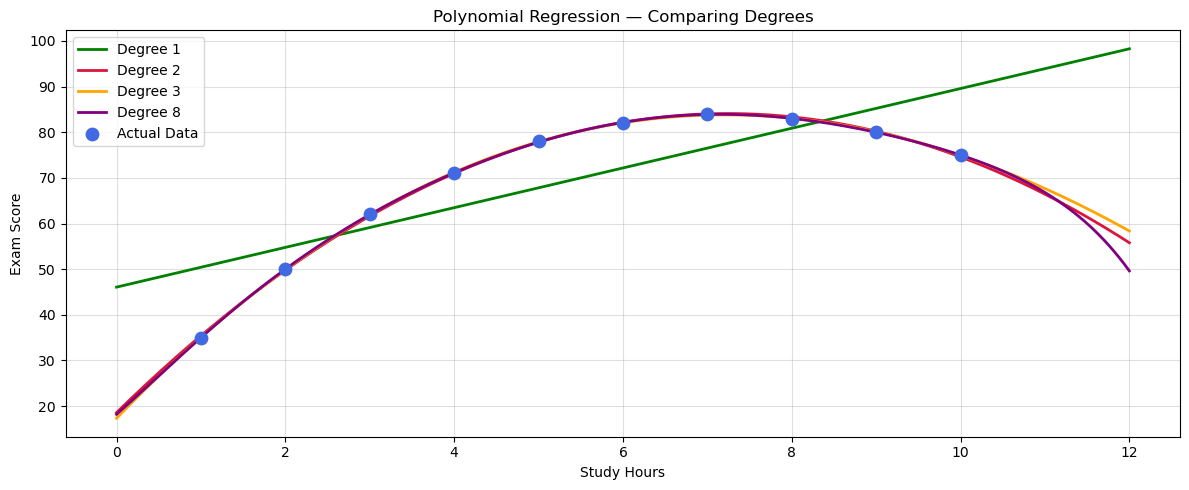

In [7]:
# ── Data ──────────────────────────────────────────────────────────
X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float).reshape(-1,1)
y = np.array([35,50,62,71,78,82,84,83,80,75], dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── What PolynomialFeatures actually does ─────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
X_transformed = poly.fit_transform(X)


print("New features       :", poly.get_feature_names_out())
# → ['x0', 'x0^2']
# It created x and x² for us automatically

# ── Build using Pipeline — the professional approach ──────────────
# Pipeline chains preprocessing + model into one clean object
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_model',  LinearRegression())
])

pipeline.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────
train_r2 = r2_score(y_train, pipeline.predict(X_train))
test_r2  = r2_score(y_test,  pipeline.predict(X_test))

print(f"\nDegree 2 → Train R²: {train_r2:.4f}  Test R²: {test_r2:.4f}")

# ── Compare multiple degrees — find the sweet spot ────────────────
print("\n Degree | Train R²  | Test R²   | Diagnosis")
print("--------|-----------|-----------|------------------")

for degree in [1, 2, 3, 4, 5, 8]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    tr2 = r2_score(y_train, pipe.predict(X_train))
    te2 = r2_score(y_test,  pipe.predict(X_test))

    if te2 < 0.5 and tr2 > 0.9:
        diagnosis = "Overfitting ❌"
    elif tr2 < 0.7:
        diagnosis = "Underfitting ⚠️"
    else:
        diagnosis = "Good ✅"

    print(f"   {degree}    |   {tr2:.4f}  |   {te2:.4f}  | {diagnosis}")

# ── Visualize all degrees ─────────────────────────────────────────
x_line = np.linspace(0, 12, 200).reshape(-1, 1)

plt.figure(figsize=(12, 5))
colors = ['green', 'crimson', 'orange', 'purple']

for i, degree in enumerate([1, 2, 3, 8]):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(X, y)
    plt.plot(x_line, pipe.predict(x_line),
             color=colors[i], linewidth=2, label=f'Degree {degree}')

plt.scatter(X, y, color='royalblue', s=80, zorder=5, label='Actual Data')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Polynomial Regression — Comparing Degrees')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()